# Erkennt unser Netz neue Handschriften?
## Tandemprojekt · Informatik · 4. Gymiklasse

**Ziel:** Ein kleines neuronales Netz mit eigenen Symbolzeichnungen trainieren und kritisch prüfen, ob es auf Zeichnungen neuer Personen übertragbar ist.

**Unser Vergleich:** Gleiche Anzahl Trainingsbilder – unterschiedlich viele zeichnende Personen.

**Arbeitsweg:** Frage → Datenplan → Training → fairer Vergleich → Auswahl → Abschlusstest → Urteil.

### So starten Sie
1. Notebook speichern; Codezellen von oben nach unten mit **Shift + Enter** ausführen.
2. Zuerst im **DEMO-Modus** den Ablauf kennenlernen. Alle Demozeichnungen sind künstlich erzeugt. Daraus folgen keine Aussagen über echte Handschriften!
3. Eigene Zeichnungen im mitgelieferten **symbolstudio.html** sammeln. Alternativ lässt sich diese Datei unten aus dem Notebook herunterladen.
4. Antworten direkt in die Markdownfelder schreiben (Doppelklick zum Bearbeiten).
5. Für das Projekt auf **EIGENE_DATEN** umstellen und den Kernel neu starten.

**Voraussetzungen:** Python 3, NumPy, Matplotlib, scikit-learn, ipywidgets. Keine GPU, kein Konto und kein Datendownload notwendig. Die Startzelle lädt die wissenschaftlichen Pakete in Pyodide; ipywidgets ist in dieser Repository-Umgebung vorbereitet. Beim ersten Start ist Internet für die Laufzeitpakete nötig. Die Zeichnungen werden nicht an einen Server gesendet. Lokal bei Bedarf: `python -m pip install notebook numpy matplotlib scikit-learn ipywidgets`.

**Wichtig:** Der Abschlusstest bleibt standardmässig aus. Diese Sperre ist eine Arbeitsregel, kein technischer Zugriffsschutz.

Die längeren technischen Codezellen sind in JupyterLab eingeklappt. Sie können sie bei Interesse öffnen; die Einstellungen bleiben sichtbar.

**Gespeicherte Beispielausgaben:** DEMO-Modus, Python/scikit-learn-Version in der Startausgabe. Neu ausführen, bevor eigene Ergebnisse interpretiert werden.

## 1 · Unsere Frage und Vermutung
**Namen / Tandem:** …  
**Anwendung:** …  
**Unsere 2–4 Symbolklassen:** …  
**Fragestellung:** …  
**Vermutung mit Begründung:** …

Beispiel: «Bei gleicher Bildanzahl erkennt ein Netz mit Trainingszeichnungen von vier Personen unbekannte Handschriften besser als mit Zeichnungen von zwei Personen.»

**Auftrag:** Was verändern Sie? Was halten Sie konstant? Woran würden Sie Ihre Vermutung als nicht bestätigt erkennen?  
**Antwort:** …

In [1]:
# Pyodide lädt die passenden WebAssembly-Pakete, ohne pip oder Installation am Gerät.
import sys
if sys.platform == "emscripten":
    import pyodide_js
    await pyodide_js.loadPackage(["numpy", "scipy", "scikit-learn", "matplotlib"])

import json, hashlib, base64, copy
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display, HTML
import ipywidgets as widgets

plt.rcParams.update({'figure.figsize': (8, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Bereit. scikit-learn', sklearn.__version__)

Bereit. scikit-learn 1.8.0


## 2 · Daten sammeln und vorher aufteilen

Verwenden Sie **mindestens acht Personen** im gemeinsamen Klassenpool:

| Rolle | Beispielcodes | Verwendung |
|---|---|---|
| Training | P01–P04 | Gewichte lernen; A nutzt P01/P02, B alle vier |
| Validierung | P05–P06 | Varianten vergleichen und auswählen |
| Abschlusstest | P07–P08 | Erst nach der Auswahl auswerten |

Pro Person und Klasse **12–15 neue Zeichnungen** sammeln. Bei drei Klassen und acht Personen sind das 288–360 Bilder. Die Lehrperson kann die Sammlung klassenweit organisieren. Dieselbe Person muss in allen Dateien denselben eindeutigen Code haben.

**Vor dem Training festhalten:** Personengruppen, Klassen, Zeichenregeln und Auswertung. Personen dürfen nicht zwischen den Rollen wechseln. Überlappende Aufnahmeserien oder Kopien sind keine unabhängigen Beispiele.

**Unsere Zeichenregeln (Grösse, Richtung, Hilfsmittel):** …  
**Wer zeichnet und welche Perspektiven fehlen?** …  
**Unsere festgelegten Personengruppen:** …

Öffnen Sie Symbolstudio im Browser. Jede gespeicherte Zeichnung wird zu 16 × 16 Helligkeitswerten: 0 = Hintergrund, 1 = Strich. Laden Sie JSON-Dateien herunter. Mehrere Downloads derselben Sammlung werden beim Import anhand der IDs zusammengeführt.

In [2]:
# Download der eigenständigen Zeichenoberfläche; ohne Python-Verbindung verwendbar.
SAMMLER_HTML = '<!doctype html><html lang="de"><meta charset="utf-8"><meta name="viewport" content="width=device-width"><title>Symbolstudio</title>\n<style>body{font:18px system-ui;background:#f1f5f9;color:#172c43;max-width:760px;margin:35px auto;padding:20px}canvas{background:white;border:2px solid #345;touch-action:none;width:320px;height:320px}button,input{font:inherit;padding:10px;margin:5px}button{background:#153f66;color:white;border:0;border-radius:6px}label{display:block}small{display:block;line-height:1.6}</style>\n<h1>Symbolstudio</h1><p>Zeichnen → speichern → Daten herunterladen.</p><small>Nur lokale Verarbeitung. Jede Person verwendet ihren eigenen, klassenweit eindeutigen Code (keinen Namen). Gleiches Symbol immer gleich beschriften. Zeichnen Sie die vereinbarten Klassen jeweils 12–15 Mal neu. Keine Kopien. Die Daten bleiben bis zum Schliessen im Arbeitsspeicher: regelmässig herunterladen!</small>\n<label>Personencode <input id="person" value="P01" maxlength="30"></label><label>Klasse <input id="label" value="Stern" maxlength="30"></label>\n<canvas id="c" width="320" height="320"></canvas><br><button id="clear">Neu zeichnen</button><button id="save">Zeichnung übernehmen</button><button id="download">JSON herunterladen</button><p id="status" role="status">0 Zeichnungen gesammelt.</p>\n<script>\nconst c=document.getElementById(\'c\'),ctx=c.getContext(\'2d\'),status=document.getElementById(\'status\');let drawing=false,dirty=false,records=[];\nfunction reset(){ctx.fillStyle=\'white\';ctx.fillRect(0,0,320,320);dirty=false;}reset();\nfunction xy(e){const r=c.getBoundingClientRect();return [(e.clientX-r.left)*320/r.width,(e.clientY-r.top)*320/r.height];}\nc.onpointerdown=e=>{e.preventDefault();c.setPointerCapture(e.pointerId);drawing=true;dirty=true;ctx.beginPath();ctx.moveTo(...xy(e));};\nc.onpointermove=e=>{if(!drawing)return;ctx.strokeStyle=\'black\';ctx.lineWidth=18;ctx.lineCap=\'round\';ctx.lineJoin=\'round\';ctx.lineTo(...xy(e));ctx.stroke();};\nc.onpointerup=()=>drawing=false;c.onpointercancel=()=>drawing=false;\ndocument.getElementById(\'clear\').onclick=reset;\ndocument.getElementById(\'save\').onclick=()=>{const person=document.getElementById(\'person\').value.trim(),label=document.getElementById(\'label\').value.trim();if(!person||!label||!dirty){status.textContent=\'Personencode, Klasse und Zeichnung erforderlich.\';return;}const mini=document.createElement(\'canvas\');mini.width=mini.height=16;const m=mini.getContext(\'2d\');m.drawImage(c,0,0,16,16);const data=m.getImageData(0,0,16,16).data;let pixels=[];for(let i=0;i<data.length;i+=4)pixels.push(Math.round((1-data[i]/255)*1000)/1000);if(pixels.reduce((a,b)=>a+b,0)<1){status.textContent=\'Bitte ein vollständiges Symbol zeichnen.\';return;}records.push({id:Date.now().toString(36)+\'-\'+Math.random().toString(36).slice(2),person,label,pixels});const counts={};records.forEach(r=>{const key=r.person+\' / \'+r.label;counts[key]=(counts[key]||0)+1;});status.textContent=records.length+\' Zeichnungen. \'+Object.entries(counts).map(([k,v])=>k+\': \'+v).join(\' · \');reset();};\ndocument.getElementById(\'download\').onclick=()=>{if(!records.length)return;const blob=new Blob([JSON.stringify({schema:\'symbolstudio-v1\',size:16,records})],{type:\'application/json\'});const a=document.createElement(\'a\');a.href=URL.createObjectURL(blob);a.download=\'symbole_\'+Date.now()+\'.json\';a.click();setTimeout(()=>URL.revokeObjectURL(a.href),1000);};\nwindow.onbeforeunload=e=>{if(records.length){e.preventDefault();e.returnValue=\'Daten heruntergeladen?\';}};\n</script></html>'
b64 = base64.b64encode(SAMMLER_HTML.encode()).decode()
display(HTML(f'<a download="symbolstudio.html" href="data:text/html;base64,{b64}">symbolstudio.html herunterladen</a>'))

### Einstellungen – diese Zelle dürfen Sie bearbeiten
Der Datensatz-Split bleibt während des Projekts fest. Zuerst DEMO nutzen; danach eigene Daten und die **vorher vereinbarten** Codes eintragen. Kleinere Netzgrössen sind keine schlechteren Noten wert.

In [3]:
MODUS = 'DEMO'  # später: 'EIGENE_DATEN'
TRAIN_PERSONEN = ['P01', 'P02', 'P03', 'P04']
WENIGE_PERSONEN = ['P01', 'P02']
VAL_PERSONEN = ['P05', 'P06']
TEST_PERSONEN = ['P07', 'P08']
BILDER_PRO_KLASSE = 24  # identisch für A und B; gleichmässig auf Personen verteilt
NEURONEN = 24
EPOCHEN = 60
LERNRATE = 0.003
SEEDS = [11, 22, 33]   # alle drei Ergebnisse auswerten, nicht den besten Lauf herauspicken
DATEN_SEED = 2026
KLASSEN_EIGEN = ['Pfeil', 'Herz', 'Stern']  # exakt wie im Symbolstudio beschriftet
# Alternative zum Upload-Widget: JSON-Dateien neben dem Notebook ablegen.
DATEIEN = []  # z.B. ['symbole_1.json', 'symbole_2.json']

In [4]:
upload = widgets.FileUpload(accept='.json', multiple=True, description='JSON wählen')
if MODUS == 'EIGENE_DATEN':
    display(upload)
    print('Erst Dateien wählen, dann die nächste Zelle ausführen.')
else:
    print('DEMO: Keine Dateien erforderlich.')

DEMO: Keine Dateien erforderlich.


### Technischer Baustein: Daten laden und prüfen
Sie müssen diesen Code nicht nachbauen. Er erzeugt Demodaten oder liest Ihre Dateien und prüft Formate, leere Bilder sowie doppelte Bilder. Änderungen an den Importregeln mit der Lehrperson besprechen.

In [5]:
def demo_daten():
    # Künstliche Symbolzeichnungen mit personenspezifischen Drehungen/Positionen.
    # Keine echten Personen, keine empirische Aussage über Handschriften.
    rng = np.random.default_rng(42)
    t = np.linspace(0, 2*np.pi, 100)
    herz = np.c_[16*np.sin(t)**3, -(13*np.cos(t)-5*np.cos(2*t)-2*np.cos(3*t)-np.cos(4*t))]/20
    a = np.arange(11)*np.pi/5 - np.pi/2
    r = np.where(np.arange(11)%2 == 0, .9, .4)
    stern = np.c_[r*np.cos(a), r*np.sin(a)]
    pfeil = np.array([[-.8,.3],[.2,.3],[.2,.7],[.9,0],[.2,-.7],[.2,-.3],[-.8,-.3],[-.8,.3]])
    formen = {'Pfeil':pfeil, 'Herz':herz, 'Stern':stern}
    yy,xx = np.mgrid[-1.3:1.3:16j,-1.3:1.3:16j]
    records=[]
    for person in range(8):
        for label, points in formen.items():
            for k in range(15):
                winkel = (person-3.5)*.07 + rng.normal(0,.06)
                rot = np.array([[np.cos(winkel),-np.sin(winkel)],[np.sin(winkel),np.cos(winkel)]])
                pts = points @ rot * rng.uniform(.8,1.0) + rng.normal(0,.07,2)
                dist = np.full((16,16), np.inf)
                for start,end in zip(pts[:-1],pts[1:]):
                    for u in np.linspace(0,1,15):
                        q = start*(1-u)+end*u
                        dist = np.minimum(dist, (xx-q[0])**2+(yy-q[1])**2)
                pixels=np.exp(-dist/(2*(.06+person*.006)**2)).ravel()
                records.append(dict(id=f'demo-{person}-{label}-{k}', person=f'P{person+1:02}',label=label,pixels=pixels.tolist()))
    return records

def importieren():
    docs=[json.loads(Path(p).read_text(encoding='utf-8')) for p in DATEIEN]
    values=upload.value.values() if isinstance(upload.value,dict) else upload.value
    docs += [json.loads(bytes(f['content']).decode('utf-8')) for f in values]
    if not docs:
        raise ValueError('Bitte JSON-Dateien hochladen oder DATEIEN eintragen.')
    by_id={}
    for doc in docs:
        if doc.get('schema') != 'symbolstudio-v1' or doc.get('size') != 16:
            raise ValueError('Dateiformat passt nicht zum Symbolstudio.')
        for rec in doc['records']:
            if rec['id'] in by_id and rec != by_id[rec['id']]:
                raise ValueError('Widersprüchliche Datensätze mit gleicher ID.')
            by_id[rec['id']]=rec
    return list(by_id.values())

if MODUS not in ['DEMO','EIGENE_DATEN']:
    raise ValueError('MODUS muss DEMO oder EIGENE_DATEN sein.')
records = demo_daten() if MODUS == 'DEMO' else importieren()
klassen = ['Pfeil','Herz','Stern'] if MODUS == 'DEMO' else KLASSEN_EIGEN
assert 2 <= len(klassen) <= 4 and len(set(klassen)) == len(klassen), '2–4 eindeutige Klassen wählen.'
records = [r for r in records if r['label'] in klassen]
assert records, 'Keine Daten für die gewählten Klassen gefunden.'
X = np.array([r['pixels'] for r in records],dtype=float)
y = np.array([klassen.index(r['label']) for r in records])
personen = np.array([r['person'] for r in records])
assert X.shape == (len(records),256), 'Jedes Bild braucht 256 Pixelwerte.'
assert np.isfinite(X).all() and X.min() >= 0 and X.max() <= 1, 'Pixel müssen zwischen 0 und 1 liegen.'
assert np.all(X.sum(axis=1)>1), 'Mindestens ein Bild ist leer.'
hashes=[hashlib.sha256(row.tobytes()).hexdigest() for row in X]
assert len(set(hashes)) == len(hashes), 'Identische Bilder gefunden: Kopien vor dem Versuch entfernen.'
assert set(TRAIN_PERSONEN).isdisjoint(VAL_PERSONEN+TEST_PERSONEN)
assert set(VAL_PERSONEN).isdisjoint(TEST_PERSONEN)
assert set(WENIGE_PERSONEN) < set(TRAIN_PERSONEN), 'A muss eine echte Teilmenge der Trainingspersonen verwenden.'
assert all(len(v)==len(set(v)) and len(v)>=2 for v in [TRAIN_PERSONEN,VAL_PERSONEN,TEST_PERSONEN,WENIGE_PERSONEN])
assert set(TRAIN_PERSONEN+VAL_PERSONEN+TEST_PERSONEN) <= set(personen), 'Personencodes fehlen in den Daten.'
idx_val = np.flatnonzero(np.isin(personen,VAL_PERSONEN))
idx_test = np.flatnonzero(np.isin(personen,TEST_PERSONEN))
for gruppe in [TRAIN_PERSONEN,VAL_PERSONEN,TEST_PERSONEN]:
    for p in gruppe:
        assert set(y[personen==p]) == set(range(len(klassen))), f'{p}: mindestens eine Klasse fehlt.'
print(MODUS, '–', len(records), 'Bilder importiert; Testbilder werden noch nicht ausgewertet.')
for p in TRAIN_PERSONEN+VAL_PERSONEN:
    print(p, dict(Counter(klassen[i] for i in y[personen==p])))
print('Pixel-Skalierung ist fest: 0–1. Es werden keine Skalierungsparameter aus Testdaten gelernt.')

DEMO – 360 Bilder importiert; Testbilder werden noch nicht ausgewertet.
P01 {'Pfeil': 15, 'Herz': 15, 'Stern': 15}
P02 {'Pfeil': 15, 'Herz': 15, 'Stern': 15}
P03 {'Pfeil': 15, 'Herz': 15, 'Stern': 15}
P04 {'Pfeil': 15, 'Herz': 15, 'Stern': 15}
P05 {'Pfeil': 15, 'Herz': 15, 'Stern': 15}
P06 {'Pfeil': 15, 'Herz': 15, 'Stern': 15}
Pixel-Skalierung ist fest: 0–1. Es werden keine Skalierungsparameter aus Testdaten gelernt.


## 3 · Trainingsdaten anschauen
**Auftrag:** Welche Unterschiede innerhalb einer Klasse sehen Sie? Welche Klassen könnten verwechselt werden? Sind die Beschriftungen eindeutig?  
**Antwort:** …

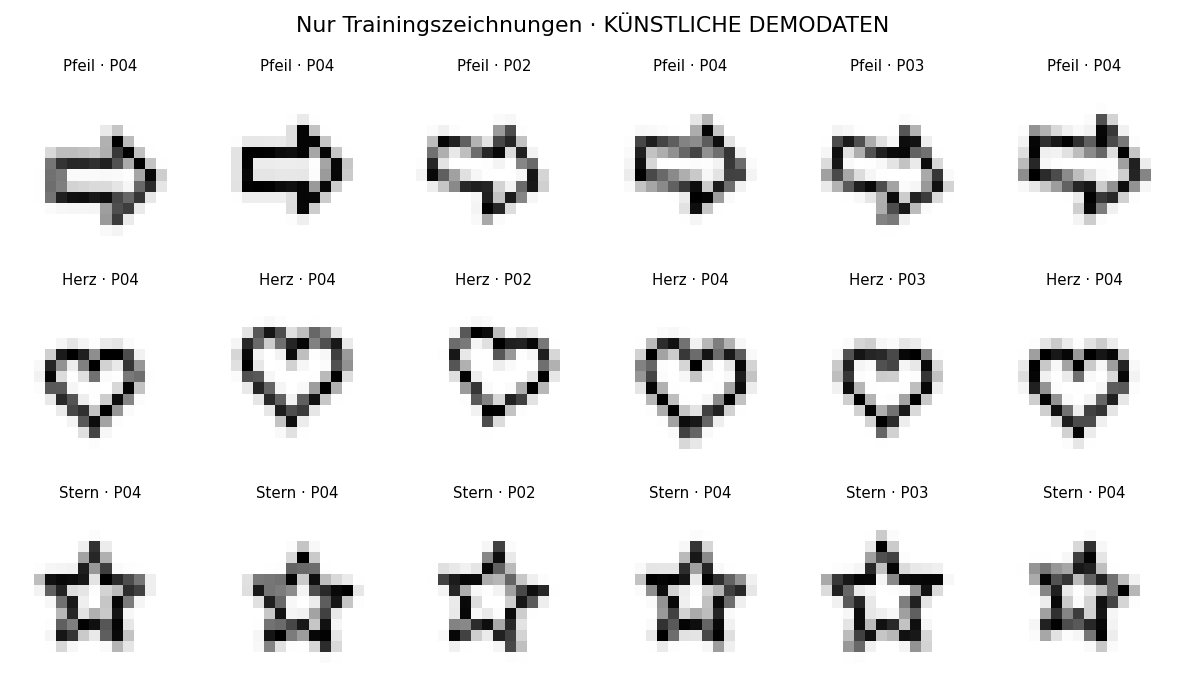

In [6]:
fig, axes = plt.subplots(len(klassen),6,figsize=(10,2*len(klassen)),squeeze=False)
for c in range(len(klassen)):
    ids=np.flatnonzero((y==c)&np.isin(personen,TRAIN_PERSONEN))
    ids=np.random.default_rng(4).choice(ids,6,replace=False)
    for ax,i in zip(axes[c],ids):
        ax.imshow(X[i].reshape(16,16),cmap='gray_r',vmin=0,vmax=1)
        ax.set_title(f'{klassen[c]} · {personen[i]}',fontsize=9);ax.axis('off')
fig.suptitle('Nur Trainingszeichnungen' + (' · KÜNSTLICHE DEMODATEN' if MODUS=='DEMO' else ''))
plt.tight_layout();plt.show()

## 4 · Fairen Vergleich vorbereiten
**A:** Zeichnungen von wenigen Personen. **B:** Zeichnungen von mehr Personen.

Beide Varianten erhalten genau gleich viele Bilder pro Klasse. B erhält einen gleichmässigen Anteil je Person. A ist kein vollständig in B enthaltener Datensatz: Die Zusammensetzung muss sich bei gleicher Grösse ändern. Pro Lauf werden Daten gezogen und das Netz neu initialisiert. Drei gepaarte Läufe zeigen erste Schwankungen, liefern aber noch keinen statistischen Beweis.

**Konstant:** Klassen, Gesamtzahl, Netzgrösse, Lernrate, Epochen und Validierungspersonen. Eine Mehrheitsklassen-Vorhersage dient als einfache Vergleichsbasis.

**Vor dem Ausführen: Unsere Vorhersage und Begründung:** …

In [7]:
def trainingsauswahl(gruppe, seed):
    assert BILDER_PRO_KLASSE % len(gruppe) == 0, 'Bildzahl muss durch die jeweilige Personenzahl teilbar sein.'
    anzahl=BILDER_PRO_KLASSE//len(gruppe)
    rng=np.random.default_rng(seed)
    ids=[]
    for p in gruppe:
        for c in range(len(klassen)):
            pool=np.flatnonzero((personen==p)&(y==c))
            assert len(pool)>=anzahl, f'{p}/{klassen[c]}: {anzahl} Bilder nötig, {len(pool)} vorhanden.'
            ids.extend(rng.choice(pool,anzahl,replace=False))
    return np.array(ids)

# Das ganze kleine Netz lernt von Grund auf: kein vortrainiertes Modell.
print(f'Netz: 256 Pixel → {NEURONEN} ReLU-Neuronen → {len(klassen)} Klassen')
print('Gewichte und Biaswerte:', (256+1)*NEURONEN+(NEURONEN+1)*len(klassen))
print('Eine Epoche = alle ausgewählten Trainingsbilder einmal zum Lernen verwenden.')
print('Die Validierungsbilder verändern keine Gewichte.')

Netz: 256 Pixel → 24 ReLU-Neuronen → 3 Klassen
Gewichte und Biaswerte: 6243
Eine Epoche = alle ausgewählten Trainingsbilder einmal zum Lernen verwenden.
Die Validierungsbilder verändern keine Gewichte.


## 5 · Netze trainieren
Das Netz passt **Gewichte und Biaswerte** an. ReLU ist die Aktivierungsfunktion der versteckten Schicht. Die Ausgaben sind Modellwahrscheinlichkeiten; hohe Werte garantieren keine richtige Antwort.

Der Code ist vorbereitet. Sie müssen erklären können, welche Daten lernen helfen und welche nur zur Beurteilung dienen. Während der Validierung läuft keine Gewichtsänderung.

**Hinweis zur Rechenzeit:** Sechs kleine Trainingsläufe. Im Browser kann dies etwas dauern.

In [8]:
def trainieren(ids, seed):
    netz=MLPClassifier(hidden_layer_sizes=(NEURONEN,), activation='relu',
                       solver='adam', batch_size=min(24,len(ids)),
                       learning_rate_init=LERNRATE, alpha=0.0001, random_state=seed)
    verlauf=[]
    for epoche in range(1,EPOCHEN+1):
        netz.partial_fit(X[ids],y[ids],classes=np.arange(len(klassen)))
        if epoche==1 or epoche%5==0 or epoche==EPOCHEN:
            verlauf.append([epoche,netz.loss_,netz.score(X[ids],y[ids]),netz.score(X[idx_val],y[idx_val])])
    return netz,np.array(verlauf)

assert len(SEEDS)>=3 and len(set(SEEDS))==len(SEEDS)
assert 1 <= NEURONEN <= 128 and 5 <= EPOCHEN <= 300
laeufe=[]
for seed in SEEDS:
    for name,gruppe in [('A',WENIGE_PERSONEN),('B',TRAIN_PERSONEN)]:
        ids=trainingsauswahl(gruppe,DATEN_SEED+seed)
        assert set(ids).isdisjoint(idx_val) and set(ids).isdisjoint(idx_test)
        netz,verlauf=trainieren(ids,seed)
        laeufe.append(dict(variante=name,seed=seed,ids=ids,netz=netz,verlauf=verlauf,
                          train=netz.score(X[ids],y[ids]),val=netz.score(X[idx_val],y[idx_val])))
        print(f'{name}, Lauf {seed}: Train {laeufe[-1]["train"]:.1%} | Validierung {laeufe[-1]["val"]:.1%}')
# Trainingsstand einfrieren: spätere Änderungen der Einstellungen erfordern neues Training.
trainingsstand=dict(modus=MODUS,neuronen=NEURONEN,epochen=EPOCHEN,lernrate=LERNRATE,
                   seeds=SEEDS.copy(),daten_seed=DATEN_SEED,bilder_pro_klasse=BILDER_PRO_KLASSE,
                   klassen=klassen.copy(),train_personen=TRAIN_PERSONEN.copy(),wenige_personen=WENIGE_PERSONEN.copy(),
                   val_personen=VAL_PERSONEN.copy(),test_personen=TEST_PERSONEN.copy())
print('Training abgeschlossen. Abschlusstest weiterhin unberührt.')
experiment_fingerprint = hashlib.sha256(json.dumps({
    'stand': trainingsstand, 'records': records,
}, sort_keys=True).encode()).hexdigest()


A, Lauf 11: Train 100.0% | Validierung 97.8%
B, Lauf 11: Train 100.0% | Validierung 96.7%
A, Lauf 22: Train 100.0% | Validierung 96.7%
B, Lauf 22: Train 100.0% | Validierung 98.9%
A, Lauf 33: Train 100.0% | Validierung 93.3%
B, Lauf 33: Train 100.0% | Validierung 98.9%
Training abgeschlossen. Abschlusstest weiterhin unberührt.


## 6 · Ergebnisse vergleichen
Die Linien zeigen einen vorab festgelegten Lauf (den ersten Seed), keine Auswahl des schönsten Verlaufs. Die Balken zeigen alle drei Läufe einzeln und deren Mittelwert. Punkte sind keine Konfidenzintervalle.

**Auftrag:** Beschreiben Sie den Unterschied in Prozentpunkten. Ist die Richtung in allen Läufen gleich? Welche Erklärung bleibt eine Vermutung?  
**Antwort:** …

Lauf 11: B minus A = -1.1 Prozentpunkte
Lauf 22: B minus A = +2.2 Prozentpunkte
Lauf 33: B minus A = +5.6 Prozentpunkte


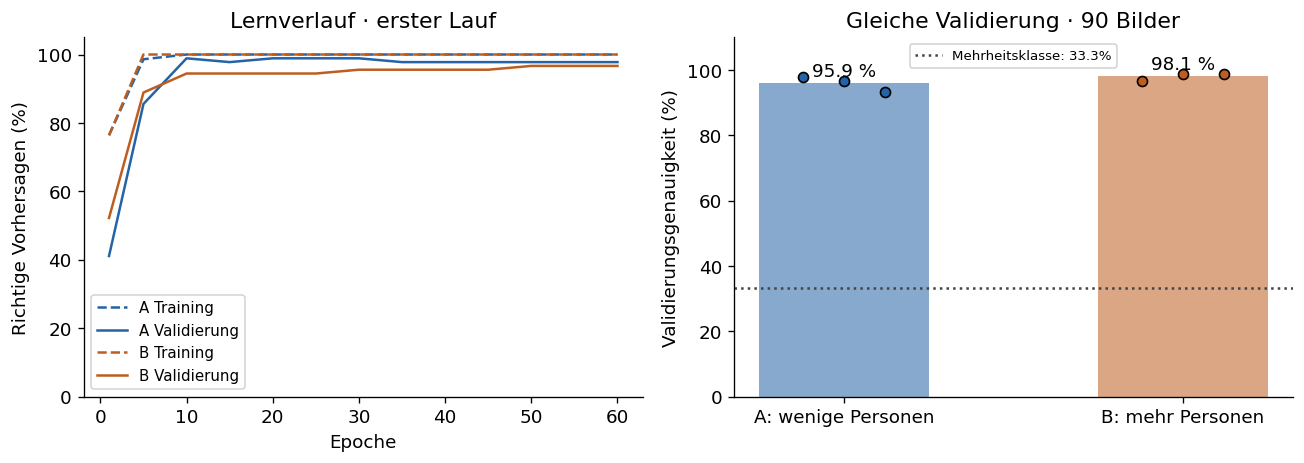

In [9]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
farben={'A':'#2563a6','B':'#bd5e20'}
for name in ['A','B']:
    run=next(r for r in laeufe if r['variante']==name and r['seed']==SEEDS[0])
    v=run['verlauf']
    axes[0].plot(v[:,0],v[:,2]*100,'--',color=farben[name],label=f'{name} Training')
    axes[0].plot(v[:,0],v[:,3]*100,'-',color=farben[name],label=f'{name} Validierung')
    values=np.array([r['val'] for r in laeufe if r['variante']==name])*100
    pos=0 if name=='A' else 1
    axes[1].bar(pos,values.mean(),width=.5,color=farben[name],alpha=.55)
    axes[1].scatter(pos+np.linspace(-.12,.12,len(values)),values,color=farben[name],edgecolors='black',zorder=3)
    axes[1].text(pos,values.mean()+2,f'{values.mean():.1f} %',ha='center')
mehrheit=Counter(y[laeufe[0]['ids']]).most_common(1)[0][0]
baseline=float(np.mean(y[idx_val]==mehrheit))
axes[1].axhline(baseline*100,color='#444',ls=':',label=f'Mehrheitsklasse: {baseline:.1%}')
axes[0].set(xlabel='Epoche',ylabel='Richtige Vorhersagen (%)',ylim=(0,105),title='Lernverlauf · erster Lauf')
axes[0].legend(fontsize=9)
axes[1].set(xticks=[0,1],xticklabels=['A: wenige Personen','B: mehr Personen'],ylabel='Validierungsgenauigkeit (%)',ylim=(0,110),title=f'Gleiche Validierung · {len(idx_val)} Bilder')
axes[1].legend(fontsize=8)
plt.tight_layout();plt.show()
for seed in SEEDS:
    a=next(r['val'] for r in laeufe if r['variante']=='A' and r['seed']==seed)
    b=next(r['val'] for r in laeufe if r['variante']=='B' and r['seed']==seed)
    print(f'Lauf {seed}: B minus A = {(b-a)*100:+.1f} Prozentpunkte')

### Deuten statt nur ablesen
- Hohe Trainings-, tiefere Validierungsgenauigkeit **kann** auf Überanpassung hinweisen. Andere Handschriften und kleine Stichproben können ebenfalls beitragen.
- Schlechte Werte auf beiden Mengen: Datenqualität, Trainingsdauer und Modell untersuchen.
- Mehr Daten oder grössere Netze helfen nicht automatisch.
- Auch viele Bilder von nur zwei Validierungspersonen erlauben begrenzte Aussagen über neue Personen.

**Was stützen unsere Daten? Was können wir nicht behaupten?** …

## 7 · Fehler untersuchen
Wählen Sie eine Variante. Angezeigt wird immer der erste Lauf, ausschliesslich auf Validierungsdaten.

P05 97.8% (45 Bilder)
P06 95.6% (45 Bilder)


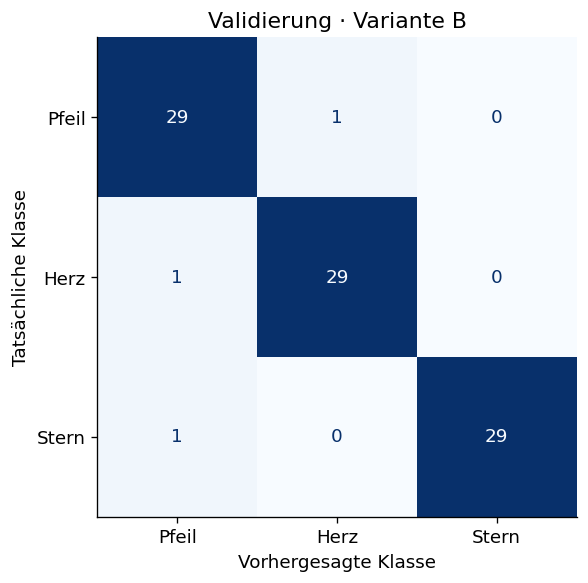

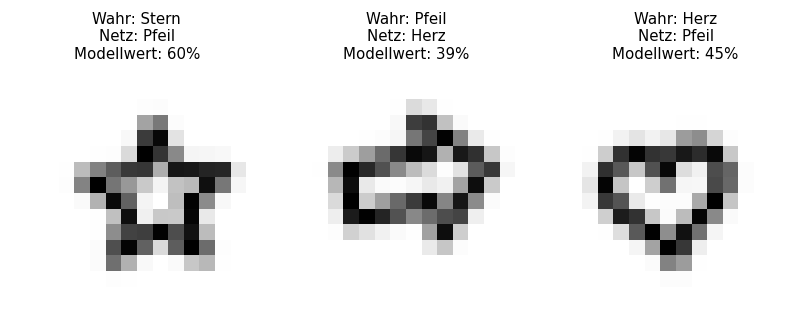

In [10]:
ANSCHAUEN = 'B'  # A oder B
run=next(r for r in laeufe if r['variante']==ANSCHAUEN and r['seed']==SEEDS[0])
pred=run['netz'].predict(X[idx_val])
fig,ax=plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(y[idx_val],pred,labels=np.arange(len(klassen))),display_labels=klassen).plot(ax=ax,cmap='Blues',colorbar=False)
ax.set(xlabel='Vorhergesagte Klasse',ylabel='Tatsächliche Klasse',title=f'Validierung · Variante {ANSCHAUEN}')
plt.tight_layout();plt.show()
falsch=idx_val[pred!=y[idx_val]][:6]
if len(falsch):
    fig,axes=plt.subplots(1,len(falsch),figsize=(2.3*len(falsch),2.8),squeeze=False)
    for ax,i in zip(axes[0],falsch):
        probs=run['netz'].predict_proba(X[i:i+1])[0];guess=int(np.argmax(probs))
        ax.imshow(X[i].reshape(16,16),cmap='gray_r',vmin=0,vmax=1)
        ax.set_title(f'Wahr: {klassen[y[i]]}\nNetz: {klassen[guess]}\nModellwert: {probs[guess]:.0%}',fontsize=9);ax.axis('off')
    plt.tight_layout();plt.show()
else:
    print('Keine Fehler in diesem Validierungslauf. Das beweist keine allgemeine Fehlerfreiheit.')
for p in VAL_PERSONEN:
    ids=np.flatnonzero(personen==p)
    print(p, f'{run["netz"].score(X[ids],y[ids]):.1%}', f'({len(ids)} Bilder)')

**Fehlerprotokoll:**

| Beobachtung | Mögliche Erklärung | Wie könnten wir die Erklärung prüfen? |
|---|---|---|
| … | … | … |
| … | … | … |

## 8 · Entscheidung vor dem Abschlusstest
**Unsere ausgewählte Variante:** …  
**Begründung mit Ergebnissen aller Läufe:** …  
**Was erwarten wir beim Abschlusstest?** …  
**Unsere Grenzen und Unsicherheiten:** …

Vereinbaren Sie die Auswahl mit der Lehrperson. Werten Sie anschliessend nur die ausgewählte Variante mit allen vorab festgelegten Seeds aus. Nach Einsicht in den Test dürfen Sie die Ergebnisse analysieren, aber keine Modellwahl oder Verbesserung mehr damit begründen und denselben Test erneut als unabhängig bezeichnen.

Der Schalter verhindert versehentliches Ausführen mit «Run all». Er ist keine Prüfungssperre.

In [11]:
AUSGEWAEHLT = 'B'   # erst nach eigener Begründung festlegen
TEST_FREIGEBEN = False  # gemeinsam mit Lehrperson auf True stellen
BEGRUENDUNG = ''    # vor Freigabe konkret ausfüllen

testergebnis=None
if not TEST_FREIGEBEN:
    print('Abschlusstest gesperrt. Erst Auswahl und Begründung abschliessen.')
else:
    assert experiment_fingerprint == hashlib.sha256(json.dumps({
        'stand': trainingsstand, 'records': records}, sort_keys=True).encode()).hexdigest(), 'Daten verändert: Kernel neu starten und das Experiment erneut durchführen.'
    assert (NEURONEN, EPOCHEN, LERNRATE, SEEDS, BILDER_PRO_KLASSE, MODUS) == (trainingsstand['neuronen'], trainingsstand['epochen'], trainingsstand['lernrate'], trainingsstand['seeds'], trainingsstand['bilder_pro_klasse'], trainingsstand['modus']), 'Einstellungen verändert: zuerst erneut trainieren.'
    assert AUSGEWAEHLT in ['A','B']
    assert len(BEGRUENDUNG.strip())>=30, 'Bitte eine inhaltliche Begründung eintragen.'
    ausgewaehlte=[r for r in laeufe if r['variante']==AUSGEWAEHLT]
    scores=[r['netz'].score(X[idx_test],y[idx_test]) for r in ausgewaehlte]
    testergebnis=dict(variante=AUSGEWAEHLT,begruendung=BEGRUENDUNG,
                     scores=scores,mittelwert=float(np.mean(scores)),n_bilder=len(idx_test))
    print(MODUS, '– Abschlusstest, Variante', AUSGEWAEHLT)
    for r,score in zip(ausgewaehlte,scores):
        print(f'Lauf {r["seed"]}: {score:.1%} ({len(idx_test)} Testbilder)')
    print(f'Mittelwert: {np.mean(scores):.1%}; Spanne: {min(scores):.1%}–{max(scores):.1%}')
    fig,ax=plt.subplots(figsize=(6,5))
    pred=ausgewaehlte[0]['netz'].predict(X[idx_test])
    ConfusionMatrixDisplay(confusion_matrix(y[idx_test],pred,labels=np.arange(len(klassen))),display_labels=klassen).plot(ax=ax,cmap='Blues',colorbar=False)
    ax.set(xlabel='Vorhergesagt',ylabel='Tatsächlich',title='Abschlusstest · erster vorab festgelegter Lauf')
    plt.tight_layout();plt.show()

Abschlusstest gesperrt. Erst Auswahl und Begründung abschliessen.


## 9 · Unser Urteil
**Antwort auf die Fragestellung (mit Zahlen):** …  
**Was hat uns überrascht?** …  
**In welchem Rahmen wäre die Anwendung brauchbar?** …  
**Was wäre der nächste Versuch mit neuen Daten?** …  
**Beitrag Person 1 / Person 2:** …  
**Verwendete Hilfen, Quellen und KI-Unterstützung:** …

### Abgabe
- Dieses Notebook mit Antworten und gespeicherten Ausgaben.
- Die ursprünglichen JSON-Dateien, damit Ergebnisse reproduzierbar bleiben.
- Das unten exportierte Versuchsprotokoll.
- Beide Personen können Datenaufteilung, Netzaufbau, Vergleich und Grenzen erklären.

**Gesprächsfragen:** Warum trennen wir nach Personen? Was lernt ein Gewicht? Was unterscheidet Epoche und Vorhersage? Weshalb ist der höchste Modellwert kein Beweis? Warum dürfen wir nach dem Abschlusstest nicht einfach weiter optimieren?

**Optionale Vertiefung – vor dem Abschlusstest:** Netzgrössen vergleichen, bei festgehaltenen Daten und sonst gleichen Einstellungen. Als getrenntes Experiment dokumentieren. Keine zusätzlichen Punkte allein für ein grosses Netz.

In [12]:
protokoll={'einstellungen':trainingsstand,'numpy':np.__version__,'sklearn':sklearn.__version__,
           'daten_sha256':hashlib.sha256(json.dumps(records,sort_keys=True).encode()).hexdigest(),
           'validierung':[{'variante':r['variante'],'seed':r['seed'],'train_accuracy':r['train'],
                          'val_accuracy':r['val'],'training_ids':[records[i]['id'] for i in r['ids']]} for r in laeufe],
           'abschlusstest':testergebnis}
payload=json.dumps(protokoll,ensure_ascii=False,indent=2)
b64=base64.b64encode(payload.encode()).decode()
display(HTML(f'<a download="Versuchsprotokoll.json" href="data:application/json;base64,{b64}">Versuchsprotokoll herunterladen</a>'))
print('Zusätzlich Notebook und ursprüngliche Zeichnungsdateien speichern.')

Zusätzlich Notebook und ursprüngliche Zeichnungsdateien speichern.


## Hinweise für die Lehrperson
**Ablaufvorschlag:** Doppellektion 1: Demo, Frage, Rollen und Datensammlung. Doppellektion 2: eigene Daten, Vergleich und Fehleranalyse. Doppellektion 3: Auswahl, Abschlusstest, Reflexion. Den gemeinsamen Datenpool vorher organisieren.

**Differenzierung:** Pflicht ist ein begründeter Vergleich. Die sichtbaren Antworten und Interpretationen sind die Eigenleistung; die Implementierung ist bereitgestellt. Hohe Accuracy allein ist kein Bewertungskriterium. Ein negativer Befund ist ein Ergebnis.

**Grenzen:** Kleine Zahl von Personen, kein kausaler Beweis, keine repräsentative Bevölkerungsstichprobe. Seed-Wiederholungen erfassen nur einen Teil der Unsicherheit. Die Demodaten sind künstlich und vergleichsweise einfach. Eigene Symbole dürfen anders aussehen; Erfolg wird nicht garantiert.

**Technik:** Keine externen Dienste. Der Sammler speichert erst mit Download dauerhaft. Upload-Widget unterstützt ipywidgets 7/8; alternativ Dateinamen verwenden. In JupyterLite heruntergeladene Notebook-/JSON-Dateien extern sichern. Vor Unterricht auf Schulgeräten testen; eine lokale Python-Prüfung ersetzt keinen JupyterLite-Browsertest.

**Quellen und Dokumentation:**
- [scikit-learn: MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- [scikit-learn: Datenlecks vermeiden](https://scikit-learn.org/stable/common_pitfalls.html)

Vorlage erstellt am 29.09.2026. Alle Demozeichnungen werden im Notebook synthetisch erzeugt.